# Grafo de Relações entre Tabelas
As definições de arestas foram criadas a partir da análise do arquivo do dicionário de dados por uma IA Generativa, que fez a transcrição das tabelas e suas chaves primárias e estrangeiras. É necessário para a análise de viabilidade de aplicar o Deep Learning Relacional (RDL) nessa base.

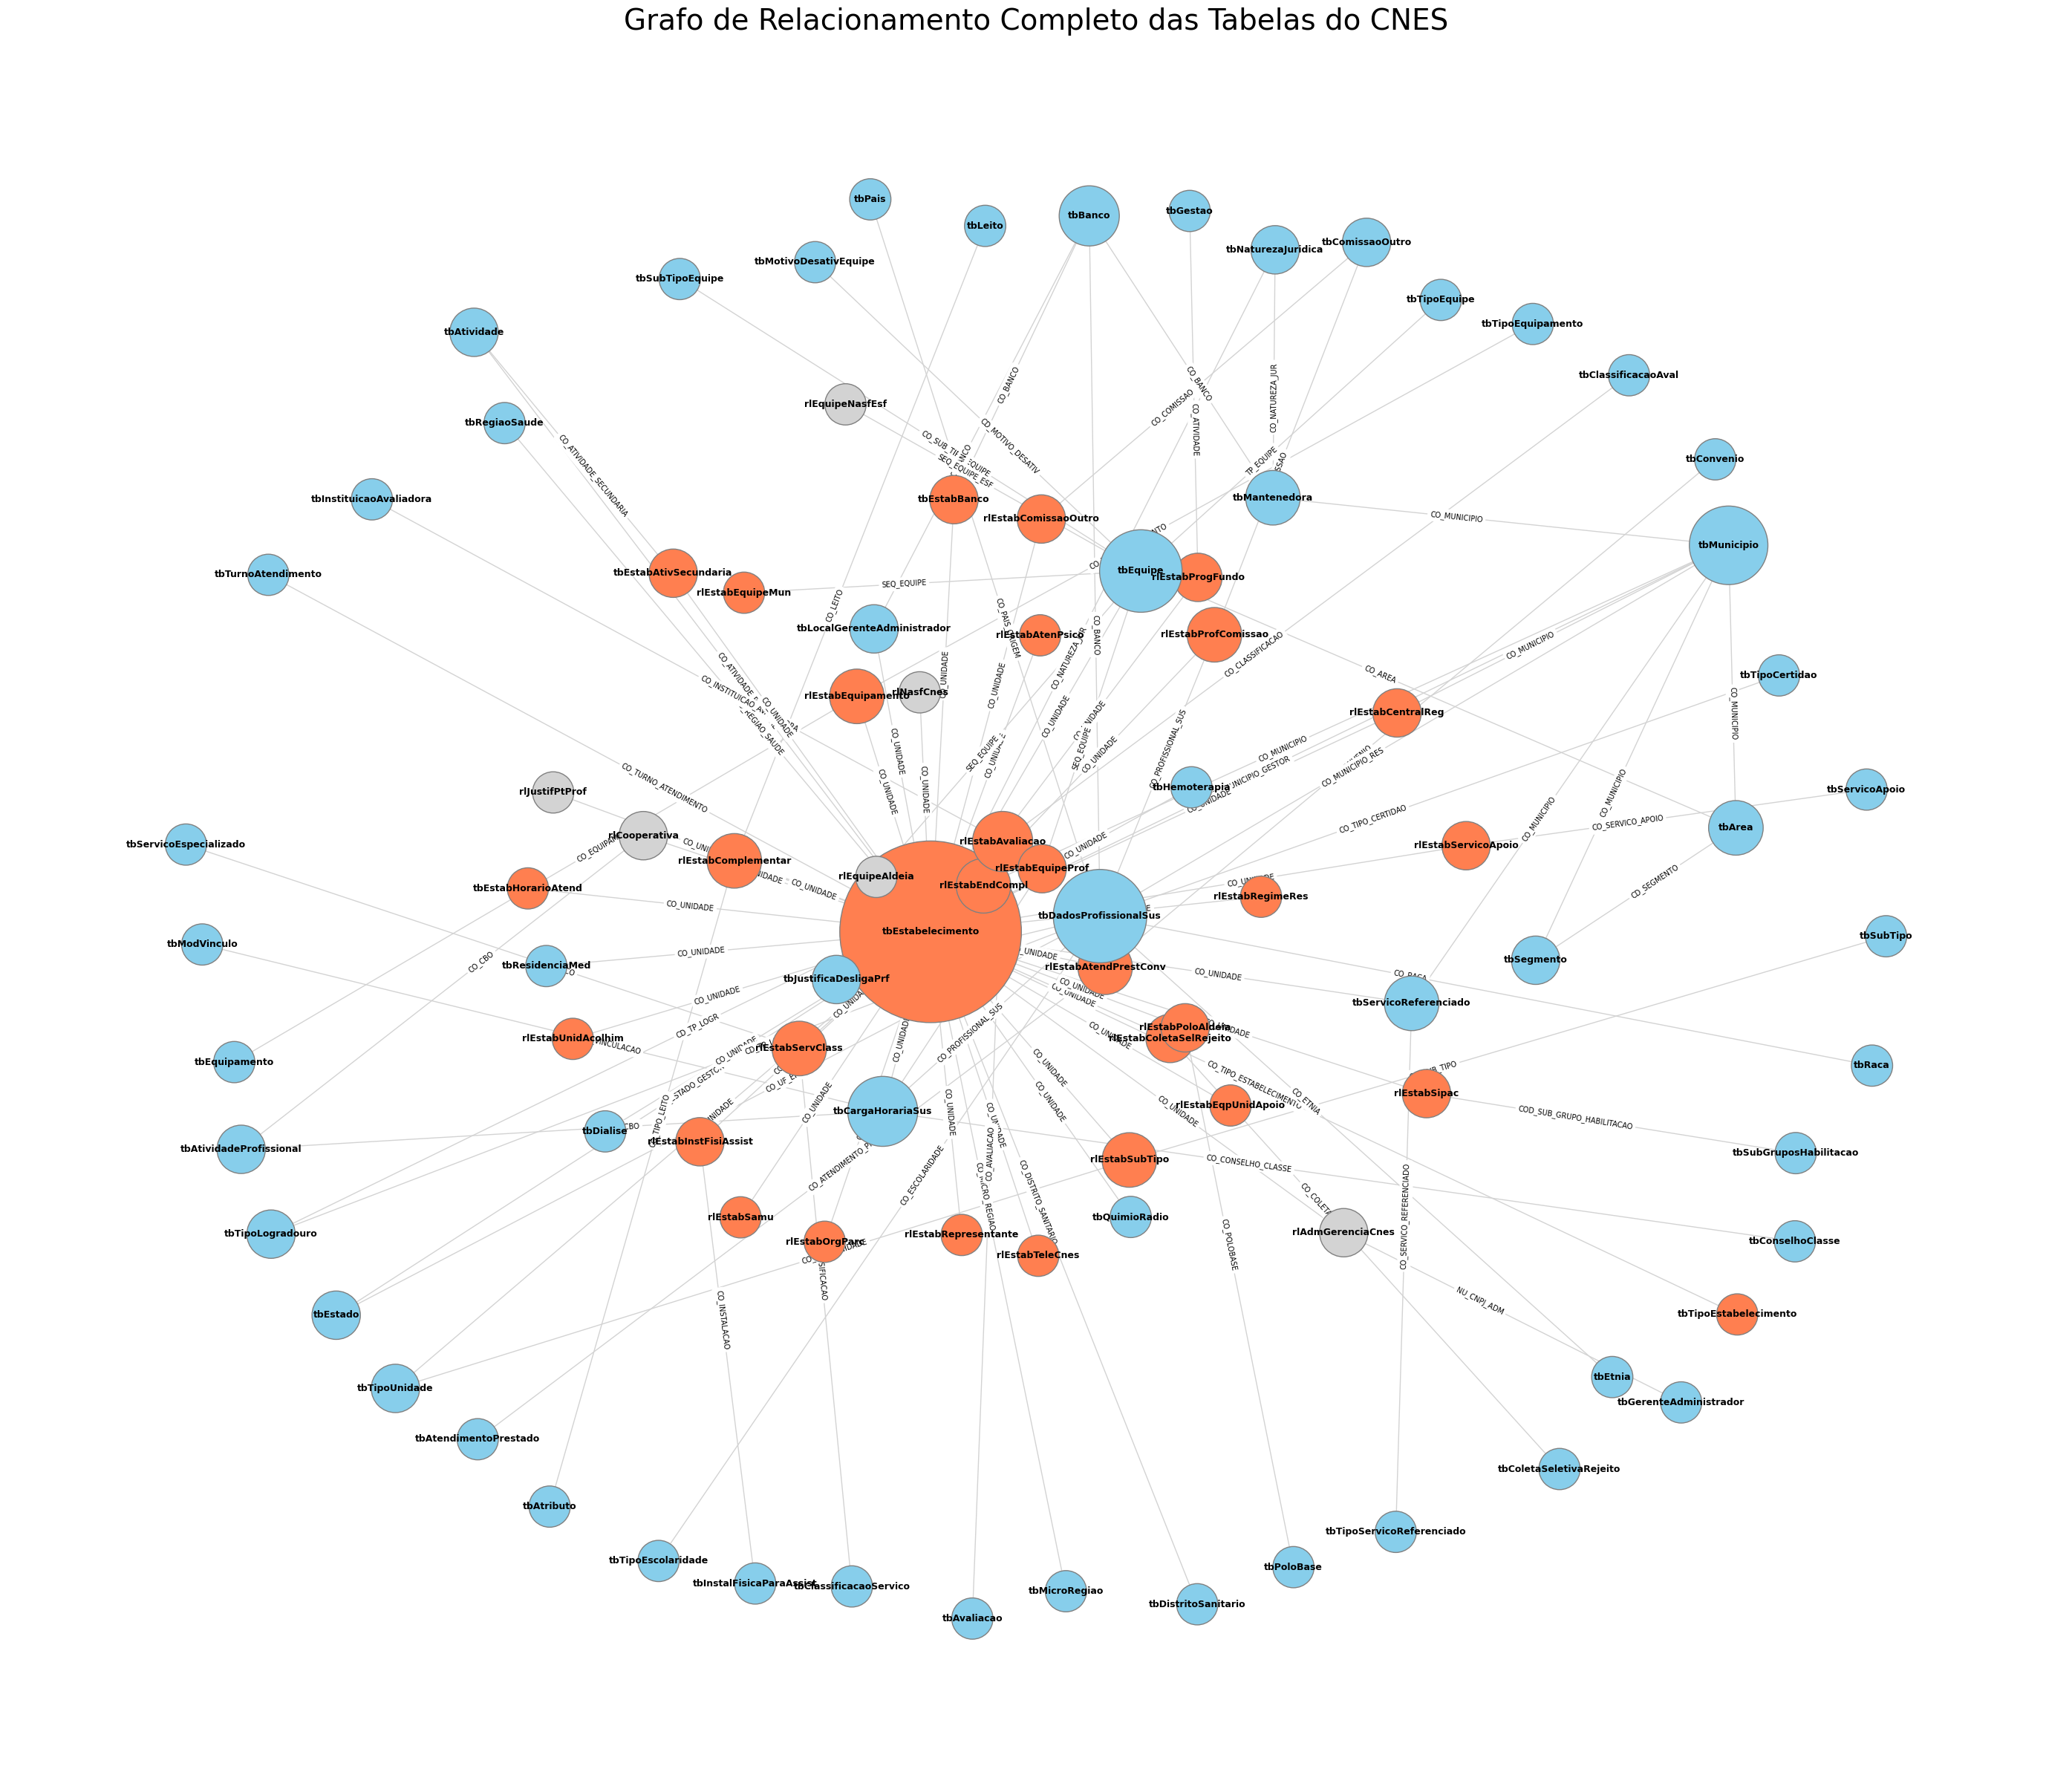

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# ===================================================================================
# DEFINIÇÃO COMPLETA DAS RELAÇÕES ENTRE AS TABELAS DO CNES
# Extraído do DICIONARIO_DE_DADOS_CNES_2025.pdf
# Formato: (Tabela Origem, Tabela Destino, Coluna de Ligação)
# ===================================================================================
edge_definitions_completo = [
    # --- Relações da TB_ESTABELECIMENTO (Base Central) ---
    ('tbEstabelecimento', 'tbMunicipio', 'CO_MUNICIPIO_GESTOR'),
    ('tbEstabelecimento', 'tbTipoUnidade', 'TP_UNIDADE'),
    ('tbEstabelecimento', 'tbTurnoAtendimento', 'CO_TURNO_ATENDIMENTO'),
    ('tbEstabelecimento', 'tbNaturezaJuridica', 'CO_NATUREZA_JUR'),
    ('tbEstabelecimento', 'tbAtividade', 'CO_ATIVIDADE_PRINCIPAL'),
    ('tbEstabelecimento', 'tbTipoEstabelecimento', 'CO_TIPO_ESTABELECIMENTO'),
    # Adicionados (Pág. 7-10):
    ('tbEstabelecimento', 'tbEstado', 'CO_ESTADO_GESTOR'), # NFCES013
    ('tbEstabelecimento', 'tbRegiaoSaude', 'CO_REGIAO_SAUDE'), # LFCES029
    ('tbEstabelecimento', 'tbMicroRegiao', 'CO_MICRO_REGIAO'),
    ('tbEstabelecimento', 'tbDistritoSanitario', 'CO_DISTRITO_SANITARIO'),

    # --- Relações da TB_MANTENEDORA ---
    ('tbMantenedora', 'tbBanco', 'CO_BANCO'),
    ('tbMantenedora', 'tbMunicipio', 'CO_MUNICIPIO'),
    ('tbMantenedora', 'tbNaturezaJuridica', 'CO_NATUREZA_JUR'),

    # --- Tabelas Relacionais ligadas a TB_ESTABELECIMENTO ---
    ('rlEstabComplementar', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabAtendPrestConv', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabProgFundo', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabColetaSelRejeito', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabServicoApoio', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('tbDialise', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('tbQuimioRadio', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabComissaoOutro', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabInstFisiAssist', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('tbServicoReferenciado', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabEquipamento', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('tbCargaHorariaSus', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('tbHemoterapia', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabServClass', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlCooperativa', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('tbEquipe', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('tbResidenciaMed', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabSipac', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabSubTipo', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabEndCompl', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('tbEstabBanco', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabPoloAldeia', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabRepresentante', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlJustifPtProf', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlNasfCnes', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabTeleCnes', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabOrgParc', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabCentralReg', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabSamu', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabUnidAcolhim', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabAtenPsico', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabRegimeRes', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabAvaliacao', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlAdmGerenciaCnes', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('rlEstabProfComissao', 'tbEstabelecimento', 'CO_UNIDADE'),
    ('tbEstabAtivSecundaria', 'tbEstabelecimento', 'CO_UNIDADE'),
    # Adicionados:
    ('tbLocalGerenteAdministrador', 'tbEstabelecimento', 'CO_UNIDADE'), # LFCES099
    ('tbJustificaDesligaPrf', 'tbEstabelecimento', 'CO_UNIDADE'), # LFCES097
    ('tbEstabHorarioAtend', 'tbEstabelecimento', 'CO_UNIDADE'), # LFCES098
    ('rlEstabEqpUnidApoio', 'tbEstabelecimento', 'CO_UNIDADE'), # LFCES095

    # --- Relações com Tabelas de Domínio (Detalhes Técnicos) ---
    ('rlEstabComplementar', 'tbLeito', 'CO_LEITO'),
    ('rlEstabComplementar', 'tbAtributo', 'CO_TIPO_LEITO'), # NFCES028
    ('rlEstabAtendPrestConv', 'tbAtendimentoPrestado', 'CO_ATENDIMENTO_PRESTADO'),
    ('rlEstabAtendPrestConv', 'tbConvenio', 'CO_CONVENIO'),
    ('rlEstabProgFundo', 'tbGestao', 'CO_ATIVIDADE'), # NFCES012
    ('rlEstabColetaSelRejeito', 'tbColetaSeletivaRejeito', 'CO_COLETA_REJEITO'),
    ('rlEstabServicoApoio', 'tbServicoApoio', 'CO_SERVICO_APOIO'),
    ('rlEstabComissaoOutro', 'tbComissaoOutro', 'CO_COMISSAO'),
    ('rlEstabInstFisiAssist', 'tbInstalFisicaParaAssist', 'CO_INSTALACAO'),
    ('rlEstabEquipamento', 'tbEquipamento', 'CO_EQUIPAMENTO'),
    ('rlEstabEquipamento', 'tbTipoEquipamento', 'CO_TIPO_EQUIPAMENTO'),
    ('rlEstabServClass', 'tbServicoEspecializado', 'CO_SERVICO'),
    ('rlEstabServClass', 'tbClassificacaoServico', 'CO_CLASSIFICACAO'),
    ('rlCooperativa', 'tbAtividadeProfissional', 'CO_CBO'), # LFCES034 -> NFCES026 (CBO)
    ('rlEstabSubTipo', 'tbTipoUnidade', 'CO_TIPO_UNIDADE'),
    ('rlEstabSubTipo', 'tbSubTipo', 'CO_SUB_TIPO'),
    ('tbEstabAtivSecundaria', 'tbAtividade', 'CO_ATIVIDADE_SECUNDARIA'), # NFCES118

    # --- Profissionais (TB_DADOS_PROFISSIONAL_SUS - LFCES018) ---
    # Adicionados (Pág. 24-26):
    ('tbDadosProfissionalSus', 'tbMunicipio', 'CO_MUNICIPIO_NASC'),
    ('tbDadosProfissionalSus', 'tbMunicipio', 'CO_MUNICIPIO_RES'),
    ('tbDadosProfissionalSus', 'tbEstado', 'CO_UF_EMISSOR'),
    ('tbDadosProfissionalSus', 'tbPais', 'CO_PAIS_ORIGEM'), # NFCES036
    ('tbDadosProfissionalSus', 'tbRaca', 'CO_RACA'), # NFCES038
    ('tbDadosProfissionalSus', 'tbEtnia', 'CO_ETNIA'),
    ('tbDadosProfissionalSus', 'tbTipoEscolaridade', 'CO_ESCOLARIDADE'),
    ('tbDadosProfissionalSus', 'tbTipoCertidao', 'CO_TIPO_CERTIDAO'),
    ('tbDadosProfissionalSus', 'tbBanco', 'CO_BANCO'),
    ('tbDadosProfissionalSus', 'tbTipoLogradouro', 'CD_TP_LOGR'),

    # --- Vínculos e Carga Horária (TB_CARGA_HORARIA_SUS - LFCES021) ---
    ('tbCargaHorariaSus', 'tbDadosProfissionalSus', 'CO_PROFISSIONAL_SUS'),
    ('tbCargaHorariaSus', 'tbAtividadeProfissional', 'CO_CBO'), # NFCES026
    ('tbCargaHorariaSus', 'tbConselhoClasse', 'CO_CONSELHO_CLASSE'),
    ('tbCargaHorariaSus', 'tbModVinculo', 'IND_VINCULACAO'),

    # --- Equipes (TB_EQUIPE - LFCES037) e Relacionados ---
    ('tbEquipe', 'tbArea', 'CO_AREA'),
    ('tbEquipe', 'tbTipoEquipe', 'TP_EQUIPE'),
    ('tbEquipe', 'tbSubTipoEquipe', 'CO_SUB_TIPO_EQUIPE'), # NFCES095
    ('tbEquipe', 'tbMotivoDesativEquipe', 'CD_MOTIVO_DESATIV'), # NFCES053
    # Relacionamentos de Equipe (Pág. 42, 62, 100):
    ('rlEstabEquipeProf', 'tbEquipe', 'SEQ_EQUIPE'),
    ('rlEstabEquipeProf', 'tbCargaHorariaSus', 'CO_PROFISSIONAL_SUS'),
    ('rlEquipeNasfEsf', 'tbEquipe', 'SEQ_EQUIPE'), # Equipe NASF
    ('rlEquipeNasfEsf', 'tbEquipe', 'SEQ_EQUIPE_ESF'), # Equipe ESF (Auto-relacionamento ou link lógico)
    ('rlEquipeAldeia', 'tbEquipe', 'SEQ_EQUIPE'),
    ('rlEstabEquipeMun', 'tbEquipe', 'SEQ_EQUIPE'),

    # --- Tabelas Geográficas e de Endereço ---
    ('tbArea', 'tbSegmento', 'CD_SEGMENTO'),
    ('tbArea', 'tbMunicipio', 'CO_MUNICIPIO'),
    ('tbSegmento', 'tbMunicipio', 'CO_MUNICIPIO'),
    ('rlEstabEndCompl', 'tbMunicipio', 'CO_MUNICIPIO'),
    ('rlEstabEndCompl', 'tbTipoLogradouro', 'CD_TP_LOGR'),
    ('rlEstabCentralReg', 'tbMunicipio', 'CO_MUNICIPIO'),
    ('rlEstabPoloAldeia', 'tbPoloBase', 'CO_POLOBASE'), # LFCES064

    # --- Outras Tabelas Específicas ---
    ('tbServicoReferenciado', 'tbTipoServicoReferenciado', 'CO_SERVICO_REFERENCIADO'), # NFCES022
    ('tbServicoReferenciado', 'tbMunicipio', 'CO_MUNICIPIO'),
    ('tbEstabBanco', 'tbBanco', 'CO_BANCO'),
    ('rlEstabSipac', 'tbSubGruposHabilitacao', 'COD_SUB_GRUPO_HABILITACAO'), # NFCES051/052/etc (Polimórfico)
    ('rlAdmGerenciaCnes', 'tbGerenteAdministrador', 'NU_CNPJ_ADM'), # NFCES101
    ('rlEstabAvaliacao', 'tbAvaliacao', 'CO_AVALIACAO'), # NFCES099
    ('rlEstabAvaliacao', 'tbClassificacaoAval', 'CO_CLASSIFICACAO'), # NFCES100
    ('rlEstabAvaliacao', 'tbInstituicaoAvaliadora', 'CO_INSTITUICAO_AVALIADORA'), # NFCES106
    ('tbJustificaDesligaPrf', 'tbDadosProfissionalSus', 'CO_PROFISSIONAL_SUS'),
    ('tbLocalGerenteAdministrador', 'tbBanco', 'CO_BANCO'),
    ('rlEstabProfComissao', 'tbDadosProfissionalSus', 'CO_PROFISSIONAL_SUS'),
    ('rlEstabProfComissao', 'tbComissaoOutro', 'CO_COMISSAO')
]

# Criar o grafo direcionado e adicionar as arestas com rótulos
G_completo = nx.DiGraph()
for source, target, label in edge_definitions_completo:
    G_completo.add_edge(source, target, label=label)

# --- Visualização do Grafo Completo ---
plt.style.use('default')
fig, ax = plt.subplots(figsize=(28, 24))

# Layout
pos_completo = nx.spring_layout(G_completo, k=0.8, iterations=100, seed=42)

# Cores e Tamanhos
color_map_completo = []
for node in G_completo:
    if 'Estab' in node:
        color_map_completo.append('coral')
    elif node.startswith('tb'):
        color_map_completo.append('skyblue')
    elif node.startswith('rl'):
        color_map_completo.append('lightgray')
    else:
        color_map_completo.append('lightgreen')

sizes_completo = [G_completo.degree(node) * 600 + 1000 for node in G_completo.nodes()]
node_labels_completo = {node: node.replace('_', '\n') for node in G_completo.nodes()}

# Desenhar
nx.draw_networkx_nodes(G_completo, pos_completo, node_size=sizes_completo, node_color=color_map_completo, edgecolors='gray', ax=ax)
nx.draw_networkx_edges(G_completo, pos_completo, arrows=True, arrowstyle='->', arrowsize=15, edge_color='lightgray', width=1.0, ax=ax)
nx.draw_networkx_labels(G_completo, pos_completo, labels=node_labels_completo, font_size=9, font_weight='bold', ax=ax)

# Rótulos das Arestas
edge_labels_completo = nx.get_edge_attributes(G_completo, 'label')
nx.draw_networkx_edge_labels(G_completo, pos_completo, edge_labels=edge_labels_completo, font_color='black', font_size=7, label_pos=0.4, ax=ax)

ax.set_title('Grafo de Relacionamento Completo das Tabelas do CNES', fontsize=28, pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig("grafo_relacionamento_cnes_completo.png", dpi=300, bbox_inches='tight')
plt.show()

# Retorna para o estilo escuro
plt.style.use("dark_background")